## Natural Language Processing (NLP) in Finance

This notebook applies the Lecture 6 methods to the annual reports (10-K filings) of US public firms.
We will explore:

- **Text preprocessing** of 10-K filings: tokenisation, stop words and lemmatisation
- **Bag of Words** and the document-term matrix
- **Sentiment analysis** using the Loughran-McDonald (LM) dictionary
- **N-gram analysis** of negation in 10-K text
- **Market reactions**: does the tone of a 10-K predict abnormal returns around its filing date?

#### Required Packages

* **nltk** - Natural Language Toolkit for Python (https://www.nltk.org)
  - Tokenisation, stop words, part-of-speech tagging and lemmatisation
* **scikit-learn** - Document-term matrix (`CountVectorizer`) and evaluation metrics
* **statsmodels** - Regressions with clustered standard errors
* **requests** - Downloading the 10-K filings and market returns
* **pandas & numpy** - Data manipulation and numerical computing
* **matplotlib, seaborn & wordcloud** - Data visualisation

```
pip install nltk scikit-learn statsmodels requests pandas numpy matplotlib seaborn wordcloud
```

In [1]:
import gzip, io, json, os, re, time, zipfile
from collections import Counter
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import requests

# NLP toolkits
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer

# Evaluation and econometrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import statsmodels.formula.api as smf
from scipy import sparse, stats

# Graphics packages
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [2]:
for package in ["punkt_tab", "stopwords", "wordnet", "averaged_perceptron_tagger_eng"]:
    nltk.download(package, quiet=True)

#### Analysis Settings

Choose the sample **before** running the analysis. Filings are drawn at random (with a fixed seed), so the
same settings always give the same sample. Larger samples give more precise estimates but take longer to
download (the full text of a 10-K is roughly 0.25 MB).

- `N_FILINGS` - number of 10-K filings to sample (`None` = all ~55,000 filings in the selected years; ~13 GB, roughly 15-30 minutes to download)
- `START_YEAR`, `END_YEAR` - filing years to include (the dataset covers filings from the mid-1990s to 2021; 1996-2008 approximates the 1994-2008 sample period of Loughran and McDonald, 2011)
- `EVENT_WINDOW` - return window around the filing date $t$, in calendar days: `"1d"` = $[t-1, t+1]$, `"5d"` = $[t-1, t+5]$, `"30d"` = $[t-1, t+30]$
- `SECTIONS` - 10-K items to analyse (`None` = the full 10-K, as in Loughran and McDonald, 2011)

In [3]:
N_FILINGS = None      # number of 10-K filings to sample; None = all filings
START_YEAR = 1996     # first filing year
END_YEAR = 2021       # last filing year
EVENT_WINDOW = "5d"   # "1d", "5d" or "30d"; "5d" is closest to the 4-trading-day window in LM (2011)
SECTIONS = None       # e.g. ["section_7"] for the MD&A only; None = the full 10-K
SEED = 42             # random seed for reproducible sampling

assert 1993 <= START_YEAR <= END_YEAR <= 2021 and EVENT_WINDOW in ("1d", "5d", "30d")

#### Financial Text Datasets

We'll work with three datasets:

**1. US Public Firm Annual Reports (10-K)** (`JanosAudran/financial-reports-sec`)
- **Description**: 10-K filings from SEC EDGAR split into their items (EDGAR-CORPUS; Loukas et al., 2021), with stock prices around each filing date from Yahoo Finance
- **Size**: ~55,000 filings from ~4,700 firms (~12 GB)
- **Use Case**: Measuring the tone of 10-Ks and relating it to the market's reaction
- **Download**: https://huggingface.co/datasets/JanosAudran/financial-reports-sec

**2. The Loughran-McDonald Master Dictionary** (1993-2024)
- **Description**: Word lists built from 10-K filings for financial sentiment analysis
- **Categories**: Positive, Negative, Uncertainty, Litigious, Strong Modal, Weak Modal, Constraining
- **Download**: https://sraf.nd.edu/loughranmcdonald-master-dictionary/ 

**3. Market Returns** (Kenneth French Data Library)
- **Description**: Daily value-weighted return of all NYSE, AMEX and Nasdaq stocks, used to adjust stock returns for market movements
- **Download**: https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html (downloaded below)

#### Downloading the 10-K Filings

The dataset stores one firm per line in 30 data files (its train, validation and test splits, which divide
firms; we use all of them), sorted by firm identifier (CIK), so reading the first $N$ lines would give a
non-random sample of the oldest registrants. Instead, `load_10k_filings` divides the
files into chunks of ~20 MB (about 7 firms each) and reads the chunks in **random order**, keeping filings
from the selected years until `N_FILINGS` filings are collected. Each firm belongs to exactly one chunk, so no
firm is read twice, and the download always ends: with `N_FILINGS = None` (or more filings than exist) every
chunk is read once. A chunk that fails because of a network error is retried up to five times before the
download stops. All of a sampled firm's filings in the period are kept, so standard errors are later
clustered by firm. The filings are cached to disk, so re-running the notebook does not download them again
(or need a network connection).

In [ ]:
REPO = "https://huggingface.co/{}datasets/JanosAudran/financial-reports-sec/{}"
CHUNK_BYTES = 20_000_000
RETRIES = 5  # attempts per request before the download stops


def with_retries(fetch, *args):
    # Call fetch(*args), retrying after network errors with waits of 2, 4, 8 and 16 seconds
    for attempt in range(1, RETRIES + 1):
        try:
            return fetch(*args)
        except requests.RequestException as error:
            if attempt == RETRIES:
                raise
            print(f"\nNetwork error ({type(error).__name__}), attempt {attempt} of {RETRIES}; retrying")
            time.sleep(2 ** attempt)


def list_files():
    # (URL, size) of each data file in the dataset's train, validation and test splits
    files = []
    for split in ("train", "validate", "test"):
        r = requests.get(REPO.format("api/", "tree/main/data/large/" + split), timeout=60)
        r.raise_for_status()
        files += [(REPO.format("", "resolve/main/" + f["path"]), f.get("lfs", f)["size"]) for f in r.json()]
    return files


def read_chunk(url, start, end):
    # Firm records whose lines start within bytes [start, end) of a data file; a retry re-reads the whole chunk
    first = max(start - 1, 0)  # begin one byte early, so a record starting exactly at `start` is kept
    firms, buf, pos, skip = [], b"", first, start > 0
    with requests.get(url, headers={"Range": f"bytes={first}-"}, stream=True, timeout=300) as r:
        r.raise_for_status()
        for block in r.iter_content(chunk_size=1 << 20):
            buf += block
            while (nl := buf.find(b"\n")) >= 0:
                if not skip:  # the first partial record belongs to the previous chunk
                    firms.append(json.loads(buf[:nl]))
                skip, pos, buf = False, pos + nl + 1, buf[nl + 1:]
                if pos >= end:
                    return firms
    if buf.strip() and not skip:  # last record in the file
        firms.append(json.loads(buf))
    return firms


def load_10k_filings(n_filings, start_year, end_year, seed, cache_dir="data"):
    # Sample n_filings 10-Ks filed in [start_year, end_year] (None = all); cache them and return the cache path
    path = f"{cache_dir}/10k_{start_year}-{end_year}_" + ("all" if n_filings is None else f"n{n_filings}_seed{seed}") + ".jsonl.gz"
    if os.path.exists(path):
        return path
    os.makedirs(cache_dir, exist_ok=True)
    chunks = [(url, a, a + CHUNK_BYTES) for url, size in with_retries(list_files) for a in range(0, size, CHUNK_BYTES)]
    order = np.random.default_rng(seed).permutation(len(chunks))  # random order, without replacement
    target = n_filings or float("inf")
    n, seen = 0, set()
    with gzip.open(path + ".part", "wt", compresslevel=3) as out, ThreadPoolExecutor(max_workers=8) as pool:
        for b in range(0, len(order), 8):
            for firms in pool.map(lambda c: with_retries(read_chunk, *c), [chunks[i] for i in order[b:b + 8]]):
                for firm in firms:
                    for f in firm["filings"]:
                        doc_id = f"{firm['cik']}_{f['reportDate'][:4]}"
                        if n < target and start_year <= int(f["filingDate"][:4]) <= end_year and doc_id not in seen:
                            seen.add(doc_id)
                            n += 1
                            out.write(json.dumps({"docID": doc_id, "cik": firm["cik"], "name": firm["name"],
                                                  "sic": firm["sic"], "exchanges": firm["exchanges"],
                                                  **{k: f[k] for k in ("filingDate", "labels", "returns", "report")}}) + "\n")
            print(f"\rRead {min(b + 8, len(order))} / {len(order)} chunks: {n:,} filings", end="")
            if n >= target:
                break
    if n_filings is not None and n < n_filings:
        print(f"\nOnly {n:,} filings were filed in {start_year}-{end_year}; all of them are used")
    os.rename(path + ".part", path)
    return path

In [5]:
CACHE = load_10k_filings(N_FILINGS, START_YEAR, END_YEAR, SEED)


def iter_filings():
    # Stream the cached filings one at a time (the full text of every filing would use a lot of memory)
    with gzip.open(CACHE, "rt") as fh:
        for line in fh:
            yield json.loads(line)


def filing_text(filing, sections=SECTIONS):
    # Join the selected 10-K items into one document d_i
    report = filing["report"]
    return "\n".join(" ".join(report[s]) for s in (sections or report) if report.get(s))


df_filings = pd.DataFrame([{"docID": f["docID"], "cik": f["cik"], "name": f["name"],
                            "exchange": "|".join(f["exchanges"]), "filingDate": f["filingDate"],
                            "label_dataset": f["labels"][EVENT_WINDOW], **f["returns"][EVENT_WINDOW]}
                           for f in iter_filings()])
df_filings["filingDate"] = pd.to_datetime(df_filings["filingDate"])

print(f"\n{len(df_filings):,} filings from {df_filings.cik.nunique():,} firms, "
      f"filed {df_filings.filingDate.min():%Y-%m} to {df_filings.filingDate.max():%Y-%m}")
df_filings.head()


54,751 filings from 4,677 firms, filed 1996-01 to 2021-09


,docID,cik,name,exchange,filingDate,label_dataset,closePriceEndDate,closePriceStartDate,endDate,ret,startDate
0,0001382821_2020,0001382821,Redfin Corp,Nasdaq,2021-02-24,negative,80.269997,90.699997,2021-03-01T00:00:00-05:00,-0.114994,2021-02-23T00:00:00-05:00
1,0001382821_2019,0001382821,Redfin Corp,Nasdaq,2020-02-12,positive,30.900000,25.110001,2020-02-18T00:00:00-05:00,0.230585,2020-02-11T00:00:00-05:00
2,0001382821_2018,0001382821,Redfin Corp,Nasdaq,2019-02-14,positive,19.100000,18.160000,2019-02-19T00:00:00-05:00,0.051762,2019-02-13T00:00:00-05:00
3,0001382821_2017,0001382821,Redfin Corp,Nasdaq,2018-02-22,negative,20.600000,21.299999,2018-02-27T00:00:00-05:00,-0.032864,2018-02-21T00:00:00-05:00
4,0001383149_2020,0001383149,INVESCO DB US DOLLAR INDEX BEARISH FUND,NYSE,2021-02-26,negative,21.490000,21.660000,2021-03-03T00:00:00-05:00,-0.007849,2021-02-25T00:00:00-05:00


### Text as Data: The Anatomy of a 10-K

Each 10-K is one document $d_i$ and the sample of filings is the corpus $\mathcal{C}$. A 10-K is organised
into items, which the dataset stores as separate sections:

| Item | Content | Dataset key |
| :-- | :-- | :-- |
| 1 | Business description | `section_1` |
| 1A | Risk factors (required from fiscal year 2005) | `section_1A` |
| 3 | Legal proceedings | `section_3` |
| 7 | Management's Discussion and Analysis (MD&A) | `section_7` |
| 7A | Market risk disclosures | `section_7A` |
| 8 | Financial statements and notes | `section_8` |

In [6]:
example = next(f for f in iter_filings() if f["report"].get("section_7"))
print(f"{example['name']}: 10-K filed {example['filingDate']}\n")
print("Item 7 (MD&A), opening sentences:\n" + " ".join(example["report"]["section_7"][:3]))

ITEMS = ["1", "1A", "1B", "2", "3", "4", "5", "6", "7", "7A", "8", "9", "9A", "9B", "10", "11", "12", "13", "14", "15"]
pd.DataFrame({f"Item {k}": [len(example["report"].get(f"section_{k}") or [])] for k in ITEMS}, index=["Sentences"])

Redfin Corp: 10-K filed 2021-02-24

Item 7 (MD&A), opening sentences:
Item 7. Management's Discussion and Analysis of Financial Condition and Results of Operations The following discussion and analysis of our financial condition and results of operations should be read together with our consolidated financial statements, the accompanying notes, and other information included in this annual report. In particular, the risk factors contained in Item 1A may reflect trends, demands, commitments, events, or uncertainties that could materially impact our results of operations and liquidity and capital resources.


,Item 1,Item 1A,Item 1B,Item 2,Item 3,Item 4,Item 5,Item 6,Item 7,Item 7A,Item 8,Item 9,Item 9A,Item 9B,Item 10,Item 11,Item 12,Item 13,Item 14,Item 15
Sentences,76,292,3,3,7,3,14,3,263,25,507,3,15,3,3,3,3,3,3,10


#### Text Preprocessing for Financial Data

We use the pipeline:

1. **Tokenisation**: Split text into tokens using NLTK
2. **Lowercasing**: Convert to lowercase for consistency
3. **Cleaning**: Drop numbers, punctuation and stop words, but keep negations and modals (`not`, `no`, `nor`, `will`), which carry tone
4. **Stemming or lemmatisation**: Reduce words to a base form (Porter stemmer, or the WordNet lemmatiser with part-of-speech tags)

In [7]:
STOP = set(stopwords.words("english")) - {"not", "no", "nor", "will"}  # keep negation/modals
POS = {"J": wordnet.ADJ, "V": wordnet.VERB, "R": wordnet.ADV}           # Penn tag -> WordNet tag
stemmer, lemmatiser = PorterStemmer(), WordNetLemmatizer()


def preprocess(doc, method="lemma"):
    out = []
    for token, tag in nltk.pos_tag(nltk.word_tokenize(doc)):  # tokenise, tag part of speech
        token = token.lower()                                 # lowercase
        if not token.isalpha() or token in STOP:              # drop numbers, punctuation, stop words
            continue
        if method == "stem":
            out.append(stemmer.stem(token))
        else:
            out.append(lemmatiser.lemmatize(token, POS.get(tag[0], wordnet.NOUN)))
    return out


sentence = next(s for s in example["report"]["section_7"] if 15 <= len(s.split()) <= 40)
print("Raw:        ", sentence)
print("Stemmed:    ", preprocess(sentence, method="stem"))
print("Lemmatised: ", preprocess(sentence))

Raw:         In particular, the risk factors contained in Item 1A may reflect trends, demands, commitments, events, or uncertainties that could materially impact our results of operations and liquidity and capital resources.
Stemmed:     ['particular', 'risk', 'factor', 'contain', 'item', 'may', 'reflect', 'trend', 'demand', 'commit', 'event', 'uncertainti', 'could', 'materi', 'impact', 'result', 'oper', 'liquid', 'capit', 'resourc']
Lemmatised:  ['particular', 'risk', 'factor', 'contain', 'item', 'may', 'reflect', 'trend', 'demand', 'commitment', 'event', 'uncertainty', 'could', 'materially', 'impact', 'result', 'operation', 'liquidity', 'capital', 'resource']


#### Bag of Words: Converting Text to Numbers

The Bag of Words (BoW) model represents each document as a vector of term counts, ignoring word order.
Stacking the vectors gives the document-term matrix $\mathbf{X} \in \mathbb{R}^{D \times V}$, where
$x_{ij}$ is the count of term $j$ in document $i$.

**Key Components:**
- **CountVectorizer** with our `preprocess` function as the tokeniser
- **Uni- and bigrams** (`ngram_range=(1, 2)`) to capture phrases such as "interest rate"
- **Document-frequency pruning**: drop rare terms (`min_df=5`) and terms found in more than 90% of documents (`max_df=0.9`), which act as corpus-specific stop words

Part-of-speech tagging is slow, so the BoW illustration uses the MD&A (Item 7) of `BOW_FILINGS` randomly chosen filings.

In [8]:
BOW_FILINGS = 100

bow_ids = set(df_filings["docID"].sample(BOW_FILINGS, random_state=SEED))
docs = [" ".join(f["report"]["section_7"]) for f in iter_filings() if f["docID"] in bow_ids and f["report"].get("section_7")]

vectorizer = CountVectorizer(tokenizer=preprocess, lowercase=False, token_pattern=None,
                             ngram_range=(1, 2), min_df=5, max_df=0.9)
X = vectorizer.fit_transform(docs)
terms = vectorizer.get_feature_names_out()
word_sum = pd.Series(np.asarray(X.sum(axis=0)).ravel(), index=terms).sort_values(ascending=False)

print(f"Document-term matrix: {X.shape[0]} documents x {X.shape[1]:,} terms, "
      f"{X.nnz / np.prod(X.shape):.1%} of entries non-zero")
df_bow = pd.DataFrame(X[:10].toarray(), columns=terms)
df_bow[word_sum.index[:8]]

Document-term matrix: 99 documents x 12,096 terms, 14.0% of entries non-zero


,million,december,revenue,tax,rate,compare,fiscal,loan
0,127,49,107,23,50,47,0,28
1,114,25,4,108,38,7,0,0
2,153,8,0,21,23,44,140,9
3,211,27,25,60,31,45,0,10
4,0,0,0,0,0,0,0,0
5,80,25,40,0,5,15,0,0
6,98,20,36,14,28,3,0,7
7,117,2,36,12,12,15,37,21
8,76,34,60,31,35,13,4,21
9,229,43,38,7,29,34,2,3


#### Visualising Word Frequencies

The most frequent terms show the vocabulary of the MD&A and can reveal preprocessing issues
(e.g. boilerplate terms that should be pruned).

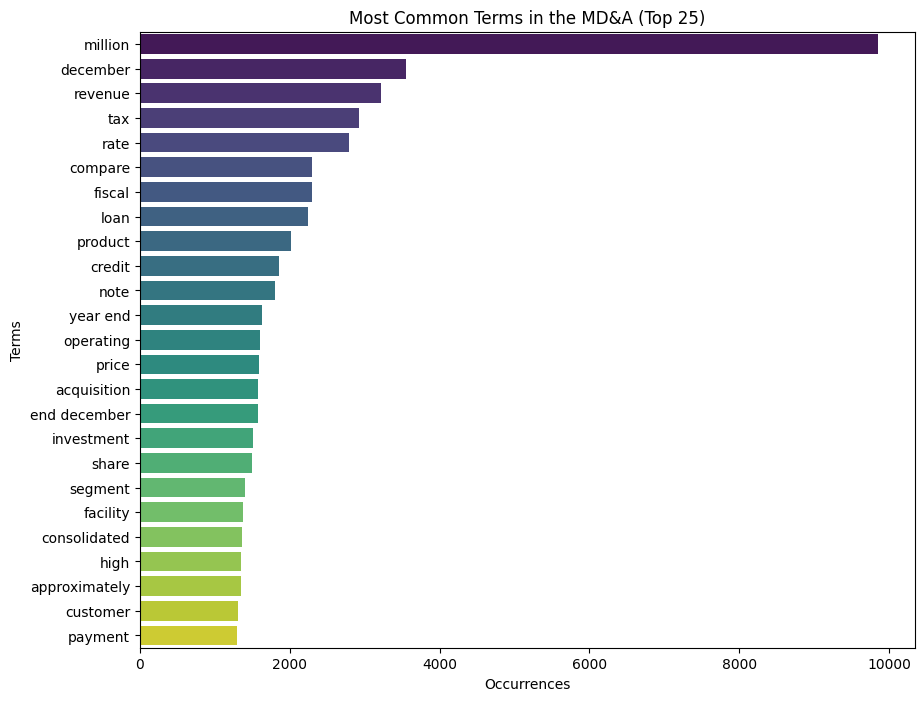

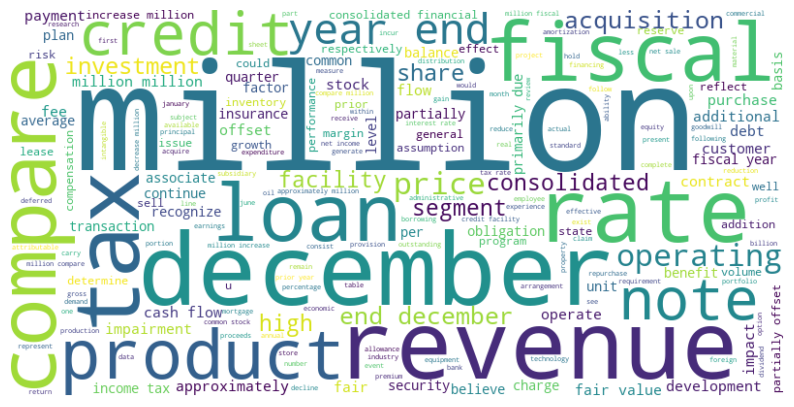

In [9]:
# Visualisation - Barplot
plt.figure(figsize=(10, 8))
sns.barplot(x=word_sum[:25].values, y=word_sum[:25].index, hue=word_sum[:25].index, palette="viridis", legend=False)
plt.title("Most Common Terms in the MD&A (Top 25)")
plt.xlabel("Occurrences")
plt.ylabel("Terms")
plt.show()

# Visualisation - Word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_sum)
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

### Sentiment Analysis in Finance

Dictionary-based sentiment analysis counts words from predefined positive and negative lists. As in the
lecture, the tone of document $d$ is

$$f_{\text{sent}}(d) = \frac{N_{\text{pos}} - N_{\text{neg}}}{N_d},$$

where $N_d$ is the number of words in $d$. Following Loughran and McDonald (2011):

- **No stemming or lemmatisation**: the LM lists already include every inflection ('challenge', 'challenged', 'challenges', ...), so we match the words as written
- **No stop-word removal**: stop words are part of $N_d$, and negations change the meaning of positive words
- **Simple negation**: a positive word preceded within three words by *no, not, none, neither, never* or *nobody* is not counted as positive
- **Tokenisation**: a fast regular expression that keeps alphabetic words, because the NLTK pipeline is too slow for full 10-Ks (~50,000 words each)

In [10]:
df_dictionary = pd.read_csv("Loughran-McDonald_MasterDictionary_1993-2024.csv", keep_default_na=False)

negative_words = set(df_dictionary.loc[df_dictionary["Negative"] > 0, "Word"].str.lower())
positive_words = set(df_dictionary.loc[df_dictionary["Positive"] > 0, "Word"].str.lower())

print(f"{len(negative_words):,} negative and {len(positive_words):,} positive words")
print("Positive examples:", sorted(positive_words)[:10])

2,345 negative and 347 positive words
Positive examples: ['able', 'abundance', 'abundant', 'acclaimed', 'accomplish', 'accomplished', 'accomplishes', 'accomplishing', 'accomplishment', 'accomplishments']


In [11]:
WORD = re.compile(r"[a-z]+")
NEGATORS = {"no", "not", "none", "neither", "never", "nobody"}
NEG_INDEX = {w: j for j, w in enumerate(sorted(negative_words))}  # column of each negative word (used in Step 2)


def lm_sentiment(text):
    # LM word counts for one document, applying simple negation to positive words
    tokens = WORD.findall(text.lower())
    pos_idx = [i for i, t in enumerate(tokens) if t in positive_words]
    negated = sum(any(w in NEGATORS for w in tokens[max(0, i - 3):i]) for i in pos_idx)
    neg_counts = Counter(t for t in tokens if t in negative_words)  # count of each negative word (Step 2)
    counts = {"N_d": len(tokens), "N_unique": len(set(tokens)), "N_neg": sum(neg_counts.values()),
              "N_pos": len(pos_idx) - negated, "N_pos_negated": negated}
    bigrams = [f"{t} {tokens[i + 1]}" for i, t in enumerate(tokens[:-1]) if t in NEGATORS]
    return counts, neg_counts, bigrams


rows, neg_cols, neg_tf, negation_bigrams = [], [], [], Counter()
for f in iter_filings():
    counts, neg_counts, bigrams = lm_sentiment(filing_text(f))
    rows.append({"docID": f["docID"], **counts})
    neg_cols.append(np.array([NEG_INDEX[w] for w in neg_counts], dtype=np.int32))  # one sparse row of the
    neg_tf.append(np.array(list(neg_counts.values()), dtype=np.int32))             # filing x negative-word matrix
    negation_bigrams.update(bigrams)

df_sent = pd.DataFrame(rows)
df_sent["neg_prop"] = df_sent["N_neg"] / df_sent["N_d"]
df_sent["pos_prop"] = df_sent["N_pos"] / df_sent["N_d"]
df_sent["tone"] = (df_sent["N_pos"] - df_sent["N_neg"]) / df_sent["N_d"]   # f_sent(d)
df_filings = df_filings.drop(columns=df_sent.columns.drop("docID"), errors="ignore").merge(df_sent, on="docID")

print(f"Filings without text: {(df_filings['N_d'] == 0).sum()}")
print(f"Share of filings with negative tone (N_neg > N_pos): {(df_filings['tone'].dropna() < 0).mean():.1%}")
df_filings[["N_d", "neg_prop", "pos_prop", "tone"]].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).round(4)

Filings without text: 245
Share of filings with negative tone (N_neg > N_pos): 98.5%


,N_d,neg_prop,pos_prop,tone
count,54751.0000,54506.0000,54506.0000,54506.0000
mean,35169.2928,0.0156,0.0049,-0.0107
std,19501.6131,0.0051,0.0018,0.0050
min,0.0000,0.0000,0.0000,-0.0535
1%,2430.0000,0.0041,0.0012,-0.0236
25%,21118.5000,0.0122,0.0037,-0.0138
50%,33204.0000,0.0155,0.0047,-0.0105
75%,46216.0000,0.0188,0.0059,-0.0074
99%,92760.0000,0.0287,0.0105,0.0007
max,245359.0000,0.0572,0.0374,0.0322


In 10-Ks, negative LM words almost always outnumber positive ones, so the **sign** of $f_{\text{sent}}(d)$
says little on its own. Tone is informative **relative to other filings**: below, filings are compared with
the median tone, or sorted into quintiles.

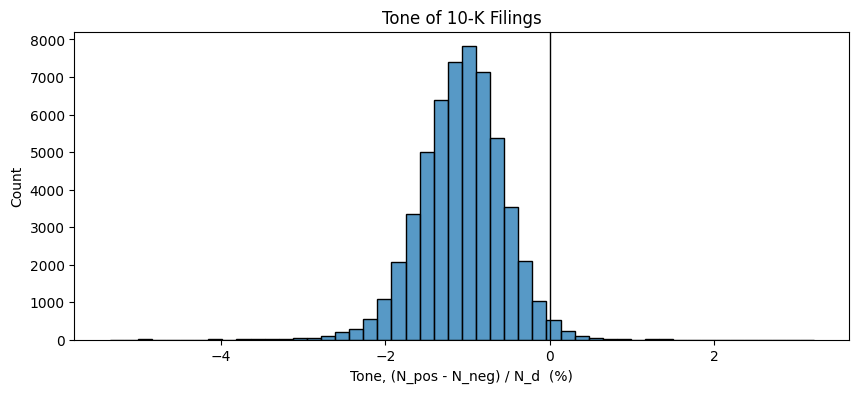

In [12]:
plt.figure(figsize=(10, 4))
sns.histplot(df_filings["tone"] * 100, bins=50)
plt.axvline(0, color="black", linewidth=1)
plt.title("Tone of 10-K Filings")
plt.xlabel("Tone, (N_pos - N_neg) / N_d  (%)")
plt.show()

#### Refinements from the Literature

Two simple refinements address weaknesses of the basic word count:

**Step 1 - Tone change** (Feldman et al., 2010): 10-K language changes little from year to year, and the
level of a firm's tone largely reflects its industry and writing style, which investors already know. What is
*new* at the filing date is the **change** in tone relative to the firm's previous 10-K:
$$\Delta f_{\text{sent}}(d_{i,t}) = f_{\text{sent}}(d_{i,t}) - f_{\text{sent}}(d_{i,t-1}),$$
computed when the previous 10-K was filed 9-15 months earlier.

**Step 2 - tf-idf weighting** (Loughran and McDonald, 2011): a few words, such as *loss* and *impairment*,
appear in almost every 10-K, often as accounting terms. Weighting each negative word $i$ in filing $j$ by
$$w_{ij} = \frac{1 + \ln tf_{ij}}{1 + \ln a_j}\,\ln\frac{D}{df_i}$$
down-weights such common words, where $tf_{ij}$ is the count of word $i$ in filing $j$, $a_j$ is the average count
per distinct word in filing $j$, $df_i$ is the number of filings containing word $i$, and $D$ is the number of filings.
The tf-idf score of a filing is the sum of $w_{ij}$ over the negative words.

In [13]:
# ---------------------------------------------------------------------------------------------
# STEP 1: Tone change from the firm's previous 10-K (Feldman et al., 2010)
# ---------------------------------------------------------------------------------------------
df_filings = df_filings.sort_values(["cik", "filingDate"])
prev = df_filings.groupby("cik")[["filingDate", "N_d", "neg_prop", "tone"]].shift(1)    # firm's previous 10-K
annual = (df_filings["filingDate"] - prev["filingDate"]).dt.days.between(270, 450) & (prev["N_d"] >= 2000)
for v in ["neg_prop", "tone"]:
    df_filings[f"d_{v}"] = (df_filings[v] - prev[v]).where(annual)                       # change, if comparable

# ---------------------------------------------------------------------------------------------
# STEP 2: tf-idf weighting of negative words (Loughran and McDonald, 2011)
# ---------------------------------------------------------------------------------------------
indptr = np.concatenate([[0], np.cumsum([len(c) for c in neg_cols])])
TF = sparse.csr_matrix((np.concatenate(neg_tf), np.concatenate(neg_cols), indptr),
                       shape=(len(neg_cols), len(NEG_INDEX)))                  # tf_ij: filings x negative words
has_text = df_sent["N_d"].to_numpy() > 0
doc_freq = np.asarray((TF[has_text] > 0).sum(axis=0)).ravel()                 # df_i
idf = np.log(has_text.sum() / np.maximum(doc_freq, 1))                         # ln(D / df_i)
log_tf = TF.astype(float)
log_tf.data = 1 + np.log(log_tf.data)                                          # 1 + ln tf_ij
a = (df_sent["N_d"] / df_sent["N_unique"].clip(lower=1)).clip(lower=1)         # a_j
neg_tfidf = np.where(has_text, (log_tf @ idf) / (1 + np.log(a)), np.nan)       # sum of w_ij over negative words
df_filings["neg_tfidf"] = df_filings["docID"].map(pd.Series(neg_tfidf, index=df_sent["docID"]))

print(f"Step 1: {df_filings['d_tone'].notna().sum():,} filings have a previous 10-K filed 9-15 months earlier")
print("Step 2: the most frequent negative words get the lowest weights (idf):")
hits = np.asarray(TF.sum(axis=0)).ravel()
words = pd.DataFrame({"Share of negative-word hits": hits / hits.sum(), "idf": idf}, index=sorted(NEG_INDEX))
words.nlargest(8, "Share of negative-word hits").round(3)

Step 1: 47,206 filings have a previous 10-K filed 9-15 months earlier
Step 2: the most frequent negative words get the lowest weights (idf):


,Share of negative-word hits,idf
loss,0.066,0.024
losses,0.047,0.042
impairment,0.038,0.128
claims,0.031,0.108
adversely,0.031,0.098
adverse,0.031,0.038
against,0.025,0.035
litigation,0.016,0.104


### N-gram Analysis: Negation in 10-K Text

Bigrams that start with a negation show how often tone is reversed by context. Standard stop-word lists
remove *no*, *not* and *nor* (see Lecture 6, Appendix A), so these patterns are lost if stop words are
removed before scoring.

Positive LM words preceded by a negation (within three words): 6.3%


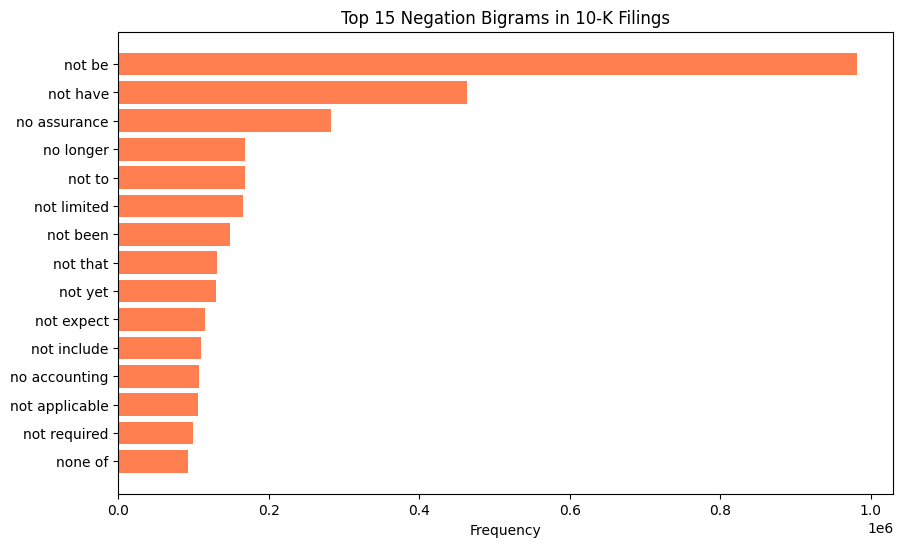

In [14]:
total_pos = df_filings["N_pos"].sum() + df_filings["N_pos_negated"].sum()
print(f"Positive LM words preceded by a negation (within three words): {df_filings['N_pos_negated'].sum() / total_pos:.1%}")

top_negations = pd.Series(dict(negation_bigrams.most_common(15)))
plt.figure(figsize=(10, 6))
plt.barh(top_negations.index, top_negations.values, color="coral")
plt.gca().invert_yaxis()
plt.xlabel("Frequency")
plt.title("Top 15 Negation Bigrams in 10-K Filings")
plt.show()

### Market Reaction to 10-K Filings

The dataset labels each filing *positive* or *negative* by the sign of its stock return over the event
window. These labels have several problems:

- **Raw returns**: over a few days, the sign of a stock's return largely reflects the market, not the filing
- **Zero returns are labelled negative**: a zero return usually means no trading (a stale price)
- **Illiquid and penny stocks**: OTC-traded and low-priced stocks have stale prices and extreme returns
- **Data errors**: some returns are implausibly large

We therefore build our own labels:

1. **Abnormal return**: the buy-and-hold return of the stock minus that of the market over the same window,
$$AR_i = \prod_{\tau \in W}(1 + R_{i\tau}) - \prod_{\tau \in W}(1 + R_{m\tau}),$$
where $R_m$ is the CRSP value-weighted market return, as in Loughran and McDonald (2011)
2. **Screens** similar to Loughran and McDonald (2011): listed on NYSE or Nasdaq, share price of at least \$3 before the filing, at least 2,000 words, and a non-zero return over the window
3. **Winsorise** abnormal returns at the 1st and 99th percentiles to limit the influence of remaining data errors
4. **Label**: *positive* if $AR_i > 0$, otherwise *negative*

In [15]:
# Daily market returns (Mkt-RF + RF) from the Kenneth French Data Library
FF_URL = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_daily_CSV.zip"
with zipfile.ZipFile(io.BytesIO(requests.get(FF_URL, timeout=60).content)) as z:
    lines = z.read(z.namelist()[0]).decode().splitlines()
header = next(i for i, line in enumerate(lines) if line.startswith(",Mkt-RF"))
ff = pd.read_csv(io.StringIO("\n".join(lines[header:])), index_col=0)
ff = ff[ff.index.astype(str).str.strip().str.fullmatch(r"\d{8}")]
ff.index = pd.to_datetime(ff.index.astype(str).str.strip(), format="%Y%m%d")
market_index = (1 + (ff["Mkt-RF"].astype(float) + ff["RF"].astype(float)) / 100).cumprod()  # value of $1 in the market

# Market return over each filing's window: close at startDate (t-1) to close at endDate
start = pd.to_datetime(df_filings["startDate"].str[:10])
end = pd.to_datetime(df_filings["endDate"].str[:10])
assert end.max() <= market_index.index.max(), "Market data do not cover the event windows"
df_filings["mkt_ret"] = market_index.asof(end).values / market_index.asof(start).values - 1
df_filings["abn_ret"] = df_filings["ret"] - df_filings["mkt_ret"]

In [16]:
screens = {
    "Listed on NYSE or Nasdaq": df_filings["exchange"].str.contains("NYSE|Nasdaq"),
    "Share price >= $3 at t-1": df_filings["closePriceStartDate"] >= 3,
    "At least 2,000 words": df_filings["N_d"] >= 2000,
    "Non-zero window return": df_filings["ret"] != 0,
}
keep = pd.Series(True, index=df_filings.index)
print(f"{'Sampled filings':<28}{keep.sum():>7,}")
for name, condition in screens.items():
    keep &= condition
    print(f"{name:<28}{keep.sum():>7,}")

sample = df_filings[keep].copy()
sample["abn_ret_w"] = sample["abn_ret"].clip(*sample["abn_ret"].quantile([0.01, 0.99]))
sample["label"] = np.where(sample["abn_ret"] > 0, "positive", "negative")

print(f"\nDataset label agrees with the market-adjusted label for {(sample['label'] == sample['label_dataset']).mean():.1%} of filings")
sample[["ret", "mkt_ret", "abn_ret", "abn_ret_w"]].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).round(4)

Sampled filings              54,751
Listed on NYSE or Nasdaq     45,816
Share price >= $3 at t-1     41,865
At least 2,000 words         41,450
Non-zero window return       40,622

Dataset label agrees with the market-adjusted label for 85.1% of filings


,ret,mkt_ret,abn_ret,abn_ret_w
count,40622.0000,40622.0000,40622.0000,40622.0000
mean,-0.0009,-0.0005,-0.0004,-0.0014
std,0.0990,0.0283,0.0939,0.0700
min,-0.8715,-0.2049,-0.8856,-0.2380
1%,-0.2648,-0.0893,-0.2380,-0.2380
25%,-0.0320,-0.0102,-0.0293,-0.0293
50%,0.0003,0.0027,-0.0009,-0.0009
75%,0.0304,0.0141,0.0266,0.0266
99%,0.2615,0.0573,0.2505,0.2505
max,7.0000,0.1825,6.9560,0.2505


#### Performance Evaluation: LM Tone vs Market Reaction

Does tone classify the market's reaction? Because almost every 10-K has negative tone, a filing is
classified *positive* if its tone is above the median. To avoid look-ahead bias, the median is computed from
the **earliest 70%** of filings (by filing date) and the classifier is evaluated on the **latest 30%**.
Two benchmarks: always predicting the most common label of the earlier period, and a random guess (expected accuracy 0.5).

Test period: 2017-02 to 2021-09 (12,187 filings)

Random guess                   accuracy 0.500 (expected)
Baseline (always 'negative')   accuracy 0.525  (95% CI 0.517 to 0.534)
LM tone                        accuracy 0.510  (95% CI 0.501 to 0.519)

Classification Report (LM tone):
              precision    recall  f1-score   support

    negative       0.52      0.76      0.62      6404
    positive       0.47      0.23      0.31      5783

    accuracy                           0.51     12187
   macro avg       0.50      0.50      0.46     12187
weighted avg       0.50      0.51      0.47     12187



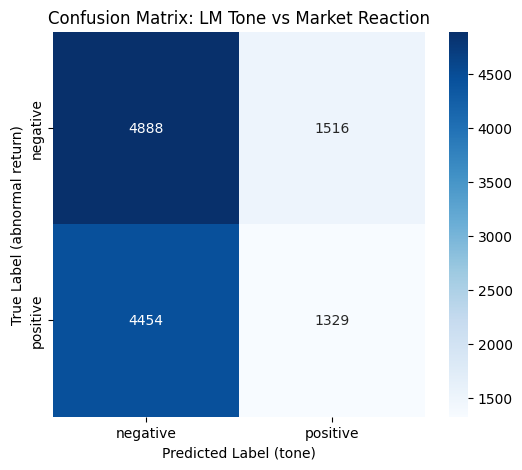

In [17]:
sample = sample.sort_values("filingDate")
split = int(0.7 * len(sample))
train, test = sample.iloc[:split], sample.iloc[split:]
threshold = train["tone"].median()
majority = train["label"].mode()[0]


def convert_sentiment_score(score):
    return "positive" if score > threshold else "negative"


test_pred = test["tone"].apply(convert_sentiment_score)
print(f"Test period: {test.filingDate.min():%Y-%m} to {test.filingDate.max():%Y-%m} ({len(test):,} filings)\n")
print(f"{'Random guess':<30} accuracy 0.500 (expected)")
for name, pred in [(f"Baseline (always '{majority}')", [majority] * len(test)), ("LM tone", test_pred)]:
    acc = accuracy_score(test["label"], pred)
    print(f"{name:<30} accuracy {acc:.3f}  (95% CI {acc - 1.96 * np.sqrt(acc * (1 - acc) / len(test)):.3f}"
          f" to {acc + 1.96 * np.sqrt(acc * (1 - acc) / len(test)):.3f})")

print("\nClassification Report (LM tone):")
print(classification_report(test["label"], test_pred))

cm = confusion_matrix(test["label"], test_pred, labels=["negative", "positive"])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["negative", "positive"], yticklabels=["negative", "positive"])
plt.title("Confusion Matrix: LM Tone vs Market Reaction")
plt.ylabel("True Label (abnormal return)")
plt.xlabel("Predicted Label (tone)")
plt.show()

#### Economic Significance

Classification ignores the **size** of the market reaction. Following Loughran and McDonald (2011), who focus
on negative words, we relate abnormal returns to the tone measures in two ways:

1. **Quintile sort**: average abnormal return by quintile of the negative-word proportion and of its change (Step 1), formed within each filing year
2. **Regression** with year fixed effects and standard errors clustered by firm and filing date:
$$AR_i = \alpha + \beta\,x_i + \gamma \log N_{d_i} + \delta_{\text{year}(i)} + \varepsilon_i$$
where $x_i$ is one standardised tone measure (levels, Step 1 changes or Step 2 tf-idf), so $\beta$ is the change in
abnormal return for a one standard deviation increase. More negative words should mean a lower $AR_i$ ($\beta < 0$),
and a better tone a higher $AR_i$ ($\beta > 0$)

The quintile confidence intervals treat filings as independent; the regression's clustered standard errors are the more reliable test.

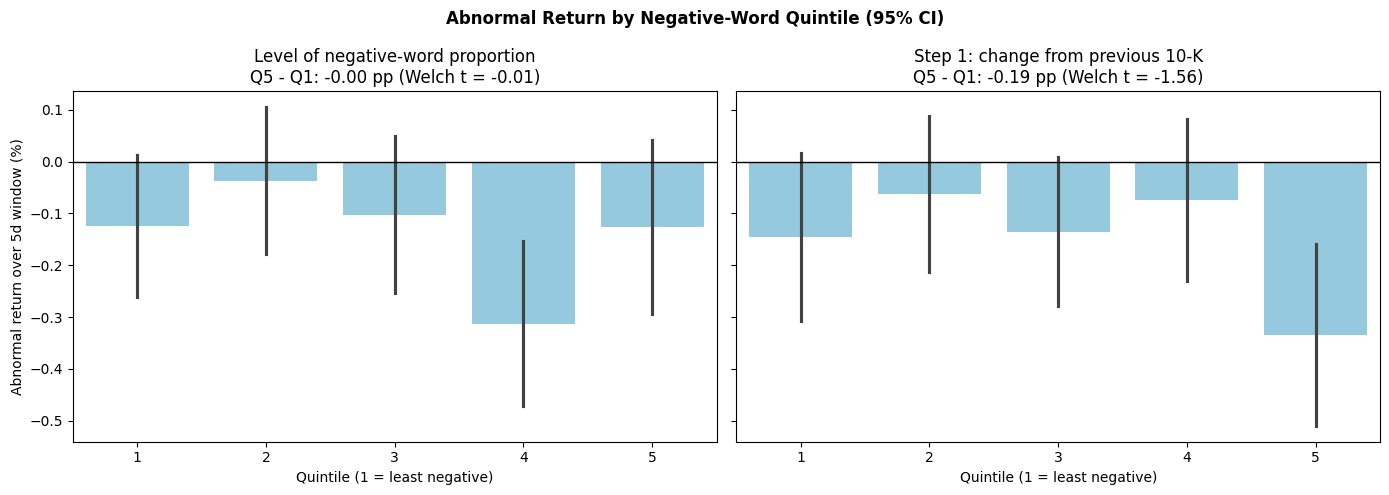

In [18]:
sample["year"] = sample["filingDate"].dt.year
sample["abn_ret_pct"] = sample["abn_ret_w"] * 100


def within_year_quintile(x):
    return pd.qcut(x.rank(method="first"), 5, labels=False) + 1 if len(x) >= 5 else pd.Series(np.nan, index=x.index)


fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (var, title) in zip(axes, [("neg_prop", "Level of negative-word proportion"),
                                   ("d_neg_prop", "Step 1: change from previous 10-K")]):
    d = sample.dropna(subset=[var]).copy()
    d["quintile"] = d.groupby("year")[var].transform(within_year_quintile)
    sns.barplot(data=d.dropna(subset=["quintile"]), x="quintile", y="abn_ret_pct", errorbar=("se", 1.96), color="skyblue", ax=ax)
    q1, q5 = (d.loc[d["quintile"] == q, "abn_ret_pct"] for q in (1, 5))
    ax.axhline(0, color="black", linewidth=1)
    ax.set(title=f"{title}\nQ5 - Q1: {q5.mean() - q1.mean():+.2f} pp (Welch t = {stats.ttest_ind(q5, q1, equal_var=False).statistic:+.2f})",
           xlabel="Quintile (1 = least negative)", ylabel=f"Abnormal return over {EVENT_WINDOW} window (%)")
fig.suptitle("Abnormal Return by Negative-Word Quintile (95% CI)", fontweight="bold")
plt.tight_layout()
plt.show()

In [19]:
MEASURES = {"neg_prop": "Negative-word proportion", "tone": "Tone",
            "d_neg_prop": "Step 1: change in negative-word proportion", "d_tone": "Step 1: change in tone",
            "neg_tfidf": "Step 2: tf-idf negative words"}
sample["log_words"] = np.log(sample["N_d"])
sd_ar = sample["abn_ret_w"].std()

results = {}
for var, label in MEASURES.items():
    d = sample.dropna(subset=[var]).copy()
    d["x"] = (d[var] - d[var].mean()) / d[var].std()   # standardised measure
    clusters = np.column_stack([pd.factorize(d["cik"])[0], pd.factorize(d["filingDate"])[0]])
    model = smf.ols("abn_ret_w ~ x + log_words + C(year)", data=d).fit(cov_type="cluster", cov_kwds={"groups": clusters})
    beta = model.params["x"]
    results[label] = {"Coefficient (pp per 1 SD)": beta * 100, "t-statistic": model.tvalues["x"],
                      "Observations": int(model.nobs), "R-squared": model.rsquared,
                      # STEP 3: best achievable sign accuracy implied by the estimate, 0.5 + arcsin(rho) / pi,
                      # with rho ~ beta / SD(abnormal return)
                      "Step 3: implied max. accuracy": 0.5 + np.arcsin(min(abs(beta) / sd_ar, 1)) / np.pi}
pd.DataFrame(results).round(3)

,Negative-word proportion,Tone,Step 1: change in negative-word proportion,Step 1: change in tone,Step 2: tf-idf negative words
Coefficient (pp per 1 SD),0.013,-0.029,-0.093,0.078,-0.163
t-statistic,0.296,-0.699,-2.246,1.915,-1.602
Observations,40622.000,40622.000,36407.000,36407.000,40622.000
R-squared,0.006,0.006,0.007,0.007,0.006
Step 3: implied max. accuracy,0.501,0.501,0.504,0.504,0.507


#### What empirical results are there regarding sentiment predicting returns?

* Loughran, T., & McDonald, B. (2011). When is a liability not a liability? Textual analysis, dictionaries, and 10-Ks. The Journal of Finance, 66(1), 35–65.

> https://doi.org/10.1111/j.1540-6261.2010.01625.x

* Feldman, R., Govindaraj, S., Livnat, J., & Segal, B. (2010). Management's tone change, post earnings announcement drift and accruals. Review of Accounting Studies, 15(4), 915–953.

* Cohen, L., Malloy, C., & Nguyen, Q. (2020). Lazy prices. The Journal of Finance, 75(3), 1371–1415.

* Tetlock, P. C. (2007). Giving content to investor sentiment: The role of media in the stock market. The Journal of Finance, 62(3), 1139–1168.

> https://www.jstor.org/stable/4622297
> https://papers.ssrn.com/sol3/papers.cfm?abstract_id=685145

* Tetlock, P. C., Saar-Tsechansky, M., & Macskassy, S. (2008). More than words: Quantifying language to measure firms' fundamentals. The Journal of Finance, 63(3), 1437–1467.

* Garcia, D. (2013). Sentiment during recessions. The Journal of Finance, 68(3), pp. 1267-1300

> https://www.jstor.org/stable/42002620
> https://papers.ssrn.com/sol3/papers.cfm?abstract_id=1571101

* Birru, J., & Young, T. (2022). Sentiment and uncertainty. Journal of Financial Economics, 146(3), 1148–1169.

> https://www.sciencedirect.com/science/article/abs/pii/S0304405X2200112X

#### What about media other than newspapers?

* Das, S. R., & Chen, M. Y. (2007). Yahoo! for Amazon: Sentiment Extraction from Small Talk on the Web. Management Science, 53(9), 1375–1388.

> https://www.jstor.org/stable/20122297

* Hailiang Chen, Prabuddha De, Yu Jeffrey Hu, & Byoung-Hyoun Hwang. (2014). Wisdom of crowds: the value of stock opinions transmitted through social media. The Review of Financial Studies.

> https://doi.org/10.1093/rfs/hhu001

#### Data source

* Loukas, L., Fergadiotis, M., Androutsopoulos, I., & Malakasiotis, P. (2021). EDGAR-CORPUS: Billions of Tokens Make The World Go Round. Proceedings of the Third Workshop on Economics and Natural Language Processing (ECONLP 2021).